# 04 Statistics and modelling
Segments with Wilson intervals, driver tests, Kaplan-Meier (`src/analysis.py`); model comparison, leakage checks, lift and campaign economics (`src/model.py`).

In [1]:
import json, pandas as pd
from IPython.display import Image, display
pd.set_option("display.max_columns", 30); pd.set_option("display.width", 160)
facts = json.load(open("reports/facts.json", encoding="utf-8"))
from src import analysis
a = analysis.run()
pd.read_csv('reports/segment_churn.csv').query('dimension in ["contract", "tenure_band", "payment_method"]')

analysis: churn 26.54%, MRR lost $139.1k, top driver Tenure (months)


,segment,customers,churned,mrr,mrr_lost,churn_rate,ci_low,ci_high,dimension
0,Month-to-month,3875,1655,257294.15,120847.10,0.427097,0.411602,0.442736,contract
1,One year,1473,166,95816.60,14118.45,0.112695,0.097544,0.129862,contract
2,Two year,1695,48,103005.85,4165.30,0.028319,0.021425,0.037345,contract
3,00-12 months,2186,1037,122629.75,68954.25,0.474382,0.453513,0.495342,tenure_band
4,13-24 months,1024,294,62829.85,23081.65,0.287109,0.260236,0.315574,tenure_band
5,25-48 months,1594,325,105093.30,27462.50,0.203890,0.184834,0.224369,tenure_band
6,49-72 months,2239,213,165563.70,19632.45,0.095132,0.083663,0.107987,tenure_band
10,Bank transfer (automatic),1544,258,103745.45,20091.90,0.167098,0.149321,0.186528,payment_method
11,Credit card (automatic),1522,232,101231.85,17946.60,0.152431,0.135250,0.171362,payment_method
12,Electronic check,2365,1071,180345.00,84288.75,0.452854,0.432885,0.472976,payment_method


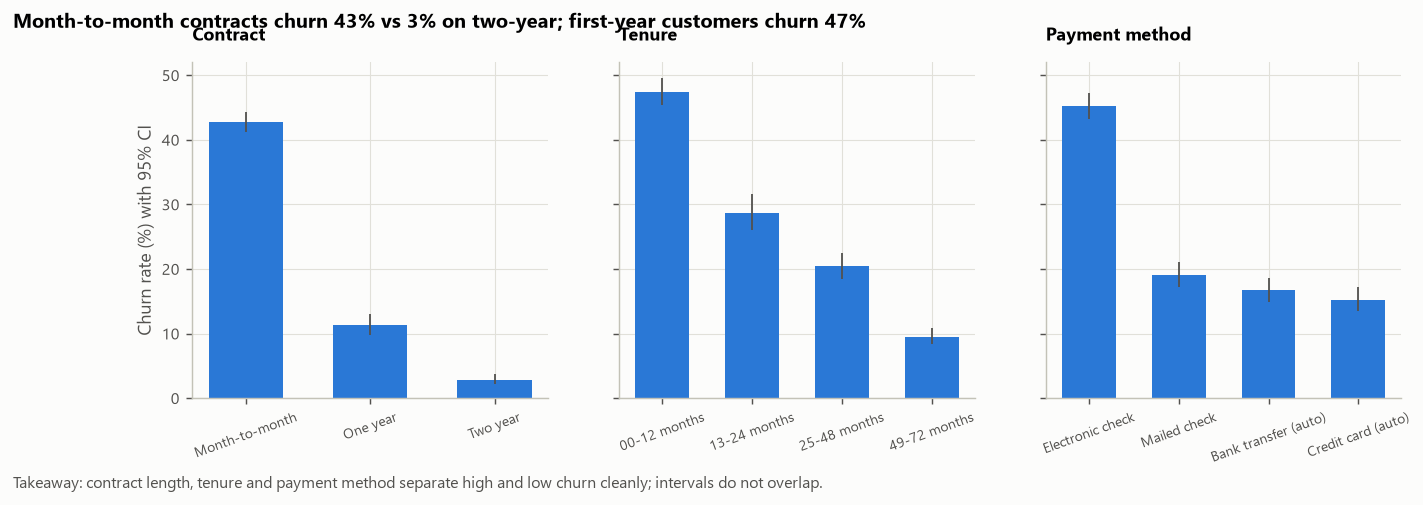

,feature,label,type,chi2,p_value,effect,effect_measure,direction,significant_bonferroni
0,tenure_months,Tenure (months),numeric,NaN,2.419636e-208,0.479734,rank-biserial |r|,lower for churners,True
1,contract,Contract,categorical,1184.596572,5.863038e-258,0.410116,Cramer's V,NaN,True
2,online_security,Online security,categorical,849.998968,2.661150e-185,0.347400,Cramer's V,NaN,True
3,tech_support,Tech support,categorical,828.197068,1.443084e-180,0.342916,Cramer's V,NaN,True
4,internet_service,Internet service,categorical,732.309590,9.571788e-160,0.322455,Cramer's V,NaN,True
5,payment_method,Payment method,categorical,648.142327,3.682355e-140,0.303359,Cramer's V,NaN,True
6,total_charges,Total charges,numeric,NaN,5.685034e-83,0.300692,rank-biserial |r|,lower for churners,True
7,online_backup,Online backup,categorical,601.812790,2.079759e-131,0.292316,Cramer's V,NaN,True
8,device_protection,Device protection,categorical,558.419369,5.505219e-122,0.281580,Cramer's V,NaN,True
9,monthly_charges,Monthly charges,numeric,NaN,3.311628e-54,0.241571,rank-biserial |r|,higher for churners,True


In [2]:
display(Image(filename='reports/figures/01_churn_by_segment.png'))
pd.read_csv('reports/drivers.csv')

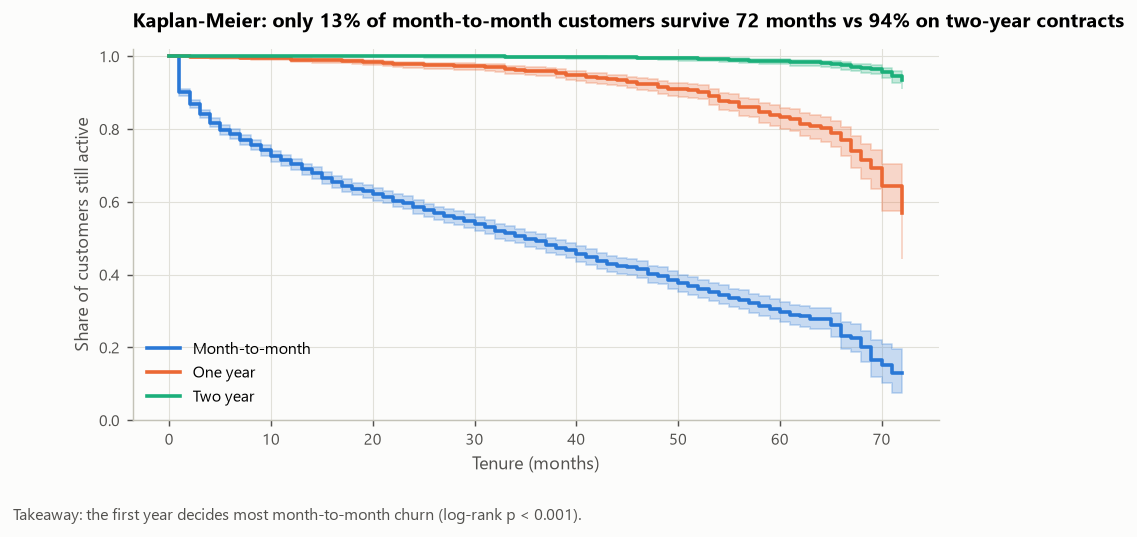

m2m_s12            0.703097
m2m_s24            0.585915
m2m_s72            0.128952
one_year_s72       0.568146
two_year_s72       0.935739
all_s12            0.843200
all_s72            0.592790
logrank_stat    2352.872538
logrank_p          0.000000
dtype: float64

In [3]:
display(Image(filename='reports/figures/04_kaplan_meier_contract.png'))
pd.Series(a['survival'])

## Models
Stratified split, CV on train only, test touched once. The tree models are kept in the table even though they do not win.

In [4]:
from src import model
m = model.run()
pd.read_csv('reports/model_comparison.csv')

model: best=Logistic regression cv_auc=0.844 test_auc=0.847; threshold 0.35; target 2356 customers, net $142,791, break-even save rate 18.5%


,model,cv_roc_auc,cv_roc_auc_sd,cv_pr_auc,test_roc_auc,test_pr_auc,precision_at_0.5,recall_at_0.5,f1_at_0.5,brier
0,Logistic regression,0.844241,0.014768,0.661354,0.846538,0.637797,0.660714,0.554604,0.603027,0.136271
1,Logistic regression (class-weighted),0.843892,0.014959,0.659027,0.846084,0.635982,0.518828,0.796574,0.628378,0.165558
2,Random forest,0.843203,0.013135,0.658782,0.842952,0.644930,0.653061,0.479657,0.553086,0.136378
3,Gradient boosting,0.838281,0.012872,0.657299,0.839324,0.644783,0.661932,0.498929,0.568987,0.137747


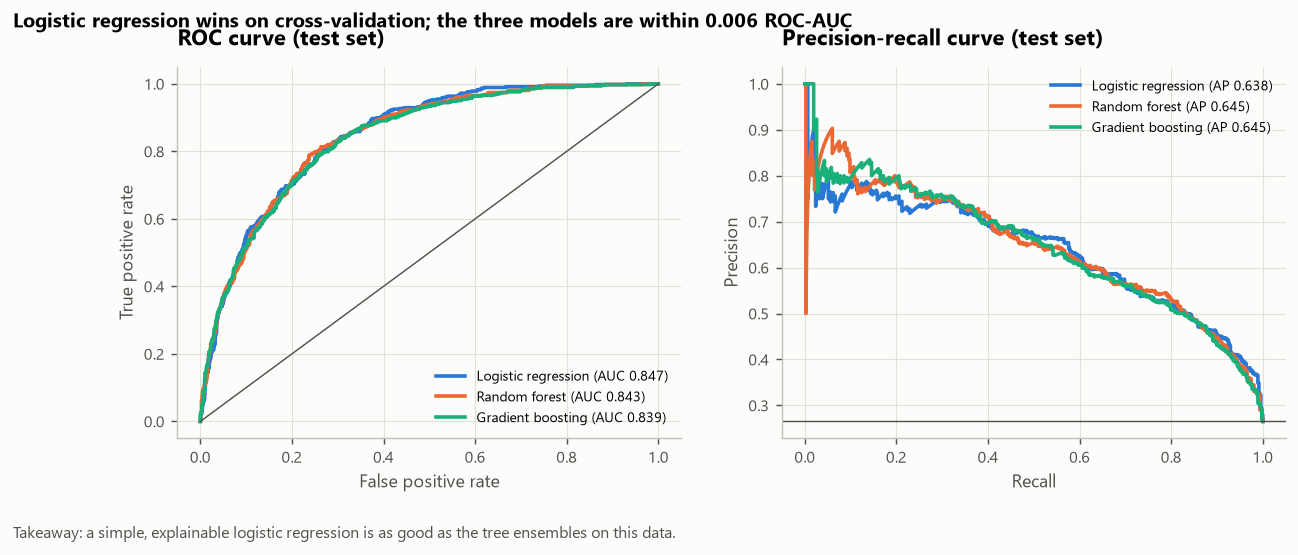

excluded_columns                           {'customer_id': 'identifier', 'churned': 'targ...
id_overlap_train_test                                                                      0
test_rows_with_identical_train_features                                                   15
shuffled_label_test_auc                                                             0.523389
auc_without_total_charges                                                           0.844675
auc_with_total_charges                                                              0.846538
max_single_feature_auc                                                              0.739867
max_single_feature                                                             tenure_months
preprocessing_inside_pipeline                                                           True
verdict                                                                     no leakage found
dtype: object

In [5]:
display(Image(filename='reports/figures/09_model_curves.png'))
pd.Series(m['leakage'])

## Lift and campaign economics

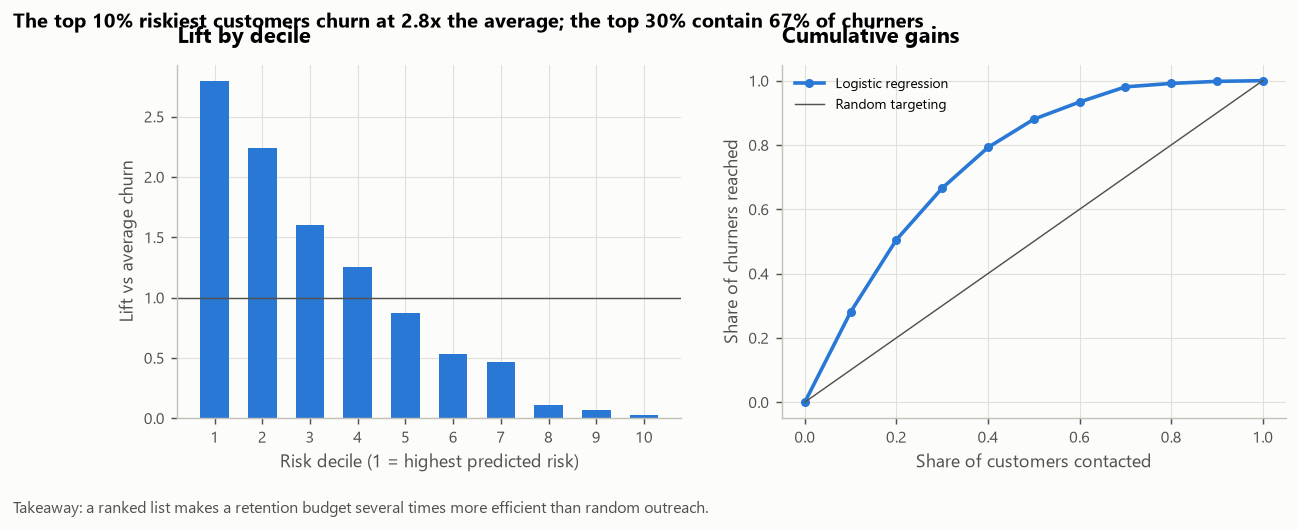

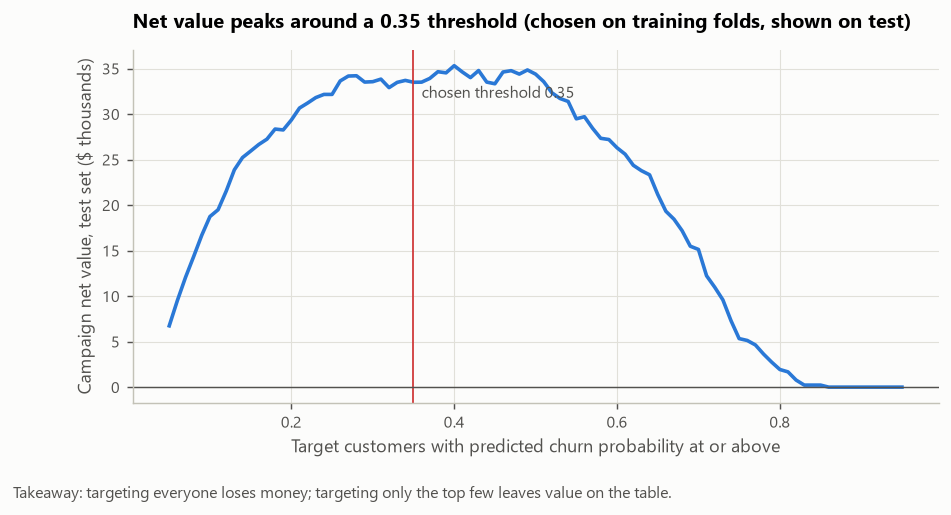

,customers,churners,churn_rate,churner_mrr,group_mrr,saved_revenue,cost,net_value,roi,breakeven_save_rate,customers_saved
model,2356.0,1325.0,0.562394,103816.40,182639.65,373739.04,230947.58,142791.46,0.618285,0.185381,397.5
rule_m2m_fiber_first_year,916.0,643.0,0.701965,53178.30,75183.15,191441.88,94799.78,96642.10,1.019434,0.148556,192.9
all_month_to_month,3875.0,1655.0,0.427097,120847.10,257294.15,435049.56,328127.98,106921.58,0.325853,0.226269,496.5
everyone,7043.0,1869.0,0.265370,139130.85,456116.60,500871.06,582554.92,-81683.86,-0.140217,0.348925,560.7


In [6]:
display(Image(filename='reports/figures/12_lift_gains.png'))
display(Image(filename='reports/figures/11_threshold_net_value.png'))
pd.DataFrame(m['campaign']['groups']).T